# Evaluation

In [1]:
from dotenv import load_dotenv
from openai import OpenAI
from wikifin_rag.rag_helper import RAGBase
from wikifin_rag.embedder import Embedder
from wikifin_rag.evaluation_utils import generate_corpus_ground_truth, evaluate
from wikifin_rag.config import PROJECT_ROOT
import pandas as pd
from psycopg import sql
import os

## Offline Evaluation Datasets
### Retrieval evaluation data

In [2]:
embedder = Embedder()

load_dotenv(override=True)
openai_client = OpenAI()

assistant = RAGBase(embedder=embedder, llm_client=openai_client)
db_client = assistant.db_client

In [3]:
def retrieve_documents(n=100):
    db_client.open_connection()
    
    db_client.cur.execute(
        sql.SQL(
            """
            SELECT
                c.document_id || '_' || c.chunk_id AS id,
                d.title,
                d.section,
                c.content
            FROM chunks c
            JOIN documents d
            ON c.document_id = d.id
            WHERE language = 'nl'
            LIMIT %s;
            """
        ),
        (n,)
    )
    documents = db_client.cur.fetchall()

    db_client.close_connection()

    return documents

In [4]:
# sets the location where the ground truth dataset is stored
dest = PROJECT_ROOT / "data"
filename = "ground_truth.csv"

# determines the size of the dataset
n_docs = 300 # number of documents to run the evaluation on
n_q = 5 # number of questions to generate per document

In [5]:
# TODO: set to True to rerun the data generation function
refresh_data = False

In [6]:
documents = retrieve_documents(n=n_docs)

In [7]:
if refresh_data or not os.path.exists(dest / filename):
    _, total_cost = generate_corpus_ground_truth(documents, llm_client=openai_client, n=n_q)

In [8]:
df_ground_truth = pd.read_csv(dest / filename)
ground_truth = df_ground_truth.to_dict(orient="records")

### RAG evaluation data

In [9]:
doc_idx = {}

for doc in documents:
    doc_idx[doc["id"]] = doc

In [10]:
def generate_rag_answer(rec):
    question = rec["question"]
    doc_id = rec["id"]
    original_doc = doc_idx[doc_id]

    answer_llm = assistant.rag(question)
    answer_orig = original_doc["answer"]

    result = {
        "question": question,
        "answer_llm": answer_llm,
        "answer_orig": answer_orig,
        "document": doc_id,
    }

    return result

In [11]:
# answer_record = generate_rag_answer(ground_truth[0])

## Retrieval metrics
### Text search
Text search optimization:
- text search returns the documents most relevant to an input query
- relevance is based on the frequency of their matching terms to the query
- term matches are weighted depending on where they appear in the document (title, description, section name, or main content)
- 

The text search function returns the documents that have the highest amount of overlap with the search query. Overlap corresponds to the frequency with which individual query terms appear in the document. The more often query terms appear in the document, the higher the document is ranked by the search function.

Occurences of overlapping terms are weighted differently depending on where they appear in the document. A change in the weighting scheme will therefore impact the document ranking for a given search query, and potentially produce a different result set.

We evaluate the quality of the search function using the mean reciprocal rank (MRR). Our goal is to identify the set of weights that yields the highest MRR on the previously generated ground truth dataset. MRR considers how highly the golden truth document is ranked by the search function for each query in the dataset.

In [12]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [13]:
from wikifin_rag.evaluation_utils import compute_relevance, compute_relevance_total

In [14]:
db_client.open_connection()

In [15]:
def text_search(query, weights=None, normalization=0):
    return assistant.db_client.text_search(query=query, num_results=5, weights=weights, normalization=normalization)

In [16]:
ground_truth_sample = ground_truth[:200]

In [17]:
def objective(args):
    normalization = args["normalization"]
    del args["normalization"]

    retrieval_metrics = evaluate(
        ground_truth_sample,
        lambda query: text_search(query=query, weights=args, normalization=normalization))

    return {'loss': -retrieval_metrics['mrr'], 'status': STATUS_OK }

In [18]:
search_space = {
    "A": hp.loguniform("title_weight", -5, 0),
    "B": hp.loguniform("description_weight", -7, 0),
    "C": hp.loguniform("section_weight", -3, 0),
    "D": 1 - hp.uniform("content_weight", 0, 1) ** 2,
    "normalization": hp.choice("normalization", [0, 1, 2, 4, 8, 16, 32])
}

In [19]:
best_params = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials(),
    trials_save_file=PROJECT_ROOT / "data" / "text_search_trials.pkl"
)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

  0%|          | 0/200 [00:00<?, ?it/s]

  2%|▏         | 1/50 [01:25<1:09:55, 85.61s/trial, best loss: -0.0612]

  0%|          | 0/200 [00:00<?, ?it/s]

  4%|▍         | 2/50 [02:51<1:08:32, 85.68s/trial, best loss: -0.0612]

...

 96%|█████████▌| 48/50 [1:07:30<02:47, 84.00s/trial, best loss: -0.2558]

  0%|          | 0/200 [00:00<?, ?it/s]

 98%|█████████▊| 49/50 [1:08:54<01:24, 84.07s/trial, best loss: -0.2558]

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 50/50 [1:10:18<00:00, 84.38s/trial, best loss: -0.2558]


In [20]:
text_search_trials = pd.read_pickle(PROJECT_ROOT / "data" / "text_search_trials.pkl")

In [21]:
text_search_trial_data = [{
    "id": trial["tid"],
    "mrr": -trial["result"]["loss"],
    "title_weight": trial["misc"]["vals"]["title_weight"][0],
    "description_weight": trial["misc"]["vals"]["description_weight"][0],
    "section_weight": trial["misc"]["vals"]["section_weight"][0],
    "content_weight": trial["misc"]["vals"]["content_weight"][0],
    "normalization": trial["misc"]["vals"]["normalization"][0]
} for trial in text_search_trials.trials]

In [22]:
text_search_trials_df = pd.DataFrame(data=text_search_trial_data)

In [23]:
text_search_trials_df.head()

,id,mrr,title_weight,description_weight,section_weight,content_weight,normalization
0,0,0.0612,0.063949,0.518979,0.525248,0.216129,6
1,1,0.0160,0.143021,0.122600,0.290806,0.709951,5
2,2,0.0520,0.037898,0.114286,0.999657,0.557140,3
3,3,0.0846,0.018878,0.739407,0.221469,0.073309,3
4,4,0.0025,0.016214,0.634263,0.259877,0.671039,2


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

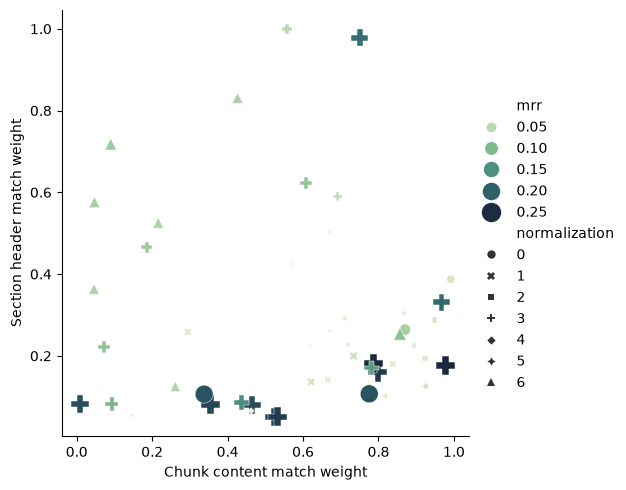

In [46]:
sns.relplot(
    data=text_search_trials_df,
    x="content_weight",
    y="section_weight",
    hue="mrr",
    palette="ch:r=-.5,l=.95",
    size="mrr",
    sizes=(15, 200),
    style="normalization"
)
plt.xlabel("Chunk content match weight")
plt.ylabel("Section header match weight")
plt.show()

> - No trend appears with respect to content match weight and MRR score
> - Higher MRR scores are generally associated with lower weighting of matches in the document section header

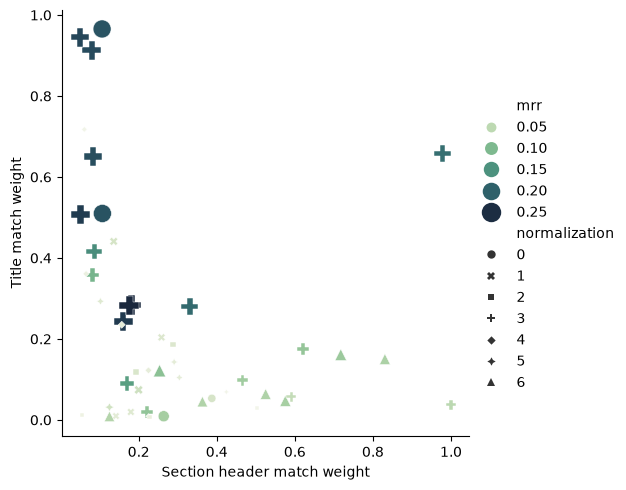

In [45]:
sns.relplot(
    data=text_search_trials_df,
    x="section_weight",
    y="title_weight",
    hue="mrr",
    palette="ch:r=-.5,l=.95",
    size="mrr",
    sizes=(15, 200),
    style="normalization"
)
plt.xlabel("Section header match weight")
plt.ylabel("Title match weight")
plt.show()

> High MRR scores are achieved across the range of weights assigned to matches in the document title

### Vector Search

In [24]:
def vector_search(query):
    return assistant.db_client.vector_search(query=query, num_results=5)

### Hybrid Search

In [25]:
def hybrid_search(query):
    return assistant.search(query=query, num_results=5)

In [26]:
db_client.close_connection()